# Helmsman — Visualizações do Motor Fuzzy
Funções de pertinência e superfície de controle para exportação em PDF.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import matplotlib
matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
import matplotlib.pyplot as plt
import skfuzzy as fuzz

from helmsman.engine import infer

## 1. Funções de pertinência — Entradas

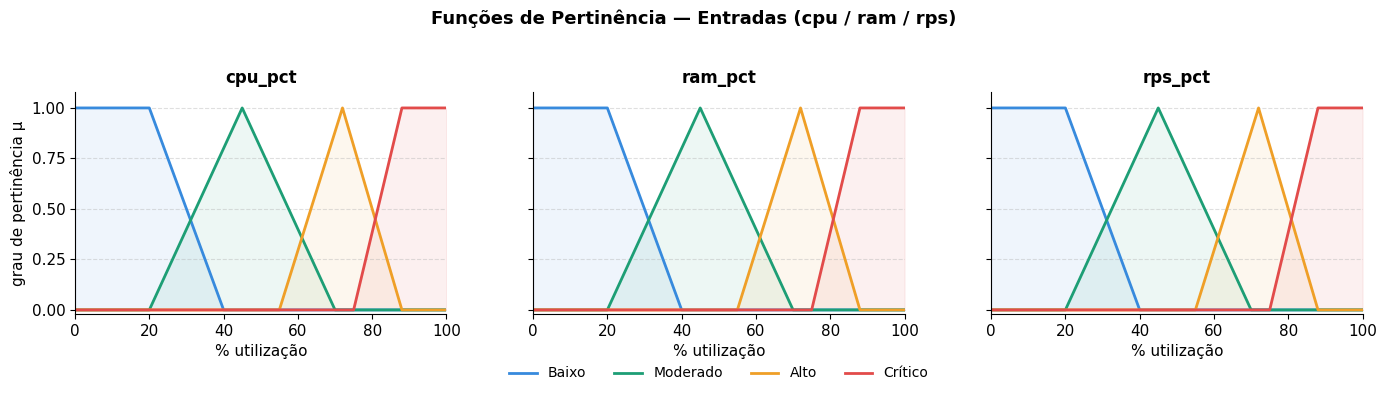

Salvo: membership_inputs.png


In [2]:
x = np.arange(0, 101, 1, dtype=float)

mf = {
    'Baixo':    fuzz.trapmf(x, [0, 0, 20, 40]),
    'Moderado': fuzz.trimf(x,  [20, 45, 70]),
    'Alto':     fuzz.trimf(x,  [55, 72, 88]),
    'Crítico':  fuzz.trapmf(x, [75, 88, 100, 100]),
}
colors = ['#378ADD', '#1D9E75', '#EF9F27', '#E24B4A']
labels = ['cpu / ram / rps (%)'] * 3

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
titles = ['cpu_pct', 'ram_pct', 'rps_pct']

for ax, title in zip(axes, titles):
    for (name, y), color in zip(mf.items(), colors):
        ax.plot(x, y, label=name, color=color, linewidth=2)
        ax.fill_between(x, y, alpha=0.08, color=color)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('% utilização')
    ax.set_ylim(-0.02, 1.08)
    ax.set_xlim(0, 100)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylabel('grau de pertinência μ')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
               ncol=4, frameon=False, fontsize=10)

plt.suptitle('Funções de Pertinência — Entradas (cpu / ram / rps)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('membership_inputs.png', dpi=180, bbox_inches='tight')
plt.show()
print('Salvo: membership_inputs.png')

## 2. Funções de pertinência — Saídas

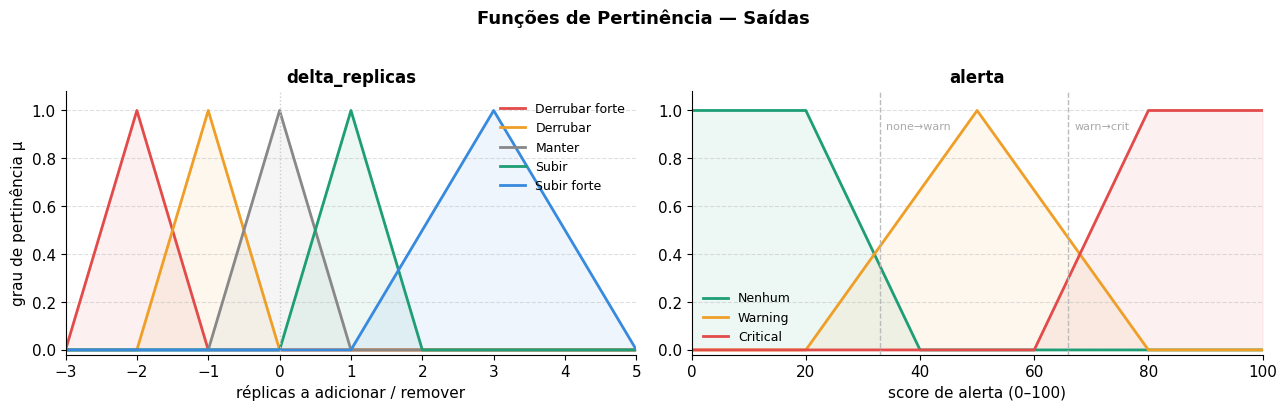

Salvo: membership_outputs.png


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# delta_replicas
xd = np.arange(-3, 5.1, 0.05)
delta_mf = {
    'Derrubar forte': (fuzz.trimf(xd, [-3, -2, -1]), '#E24B4A'),
    'Derrubar':       (fuzz.trimf(xd, [-2, -1,  0]), '#EF9F27'),
    'Manter':         (fuzz.trimf(xd, [-1,  0,  1]), '#888888'),
    'Subir':          (fuzz.trimf(xd, [ 0,  1,  2]), '#1D9E75'),
    'Subir forte':    (fuzz.trimf(xd, [ 1,  3,  5]), '#378ADD'),
}
for name, (y, color) in delta_mf.items():
    ax1.plot(xd, y, label=name, color=color, linewidth=2)
    ax1.fill_between(xd, y, alpha=0.08, color=color)
ax1.set_title('delta_replicas', fontsize=12, fontweight='bold')
ax1.set_xlabel('réplicas a adicionar / remover')
ax1.set_ylabel('grau de pertinência μ')
ax1.set_xlim(-3, 5)
ax1.set_ylim(-0.02, 1.08)
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.axvline(0, color='#ccc', linewidth=1, linestyle=':')
ax1.legend(frameon=False, fontsize=9)

# alerta
xa = np.arange(0, 101, 1, dtype=float)
alert_mf = {
    'Nenhum':   (fuzz.trapmf(xa, [0,  0, 20, 40]),   '#1D9E75'),
    'Warning':  (fuzz.trimf( xa, [20, 50, 80]),       '#EF9F27'),
    'Critical': (fuzz.trapmf(xa, [60, 80, 100, 100]), '#E24B4A'),
}
for name, (y, color) in alert_mf.items():
    ax2.plot(xa, y, label=name, color=color, linewidth=2)
    ax2.fill_between(xa, y, alpha=0.08, color=color)
    # marca a fronteira de classificação
for xv, label in [(33, 'none→warn'), (66, 'warn→crit')]:
    ax2.axvline(xv, color='#bbb', linewidth=1, linestyle='--')
    ax2.text(xv+1, 0.92, label, fontsize=8, color='#aaa')
ax2.set_title('alerta', fontsize=12, fontweight='bold')
ax2.set_xlabel('score de alerta (0–100)')
ax2.set_xlim(0, 100)
ax2.set_ylim(-0.02, 1.08)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
ax2.legend(frameon=False, fontsize=9)

plt.suptitle('Funções de Pertinência — Saídas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('membership_outputs.png', dpi=180, bbox_inches='tight')
plt.show()
print('Salvo: membership_outputs.png')

## 3. Superfície de controle 3D — cpu_pct × rps_pct → delta_replicas (ram = 50%)

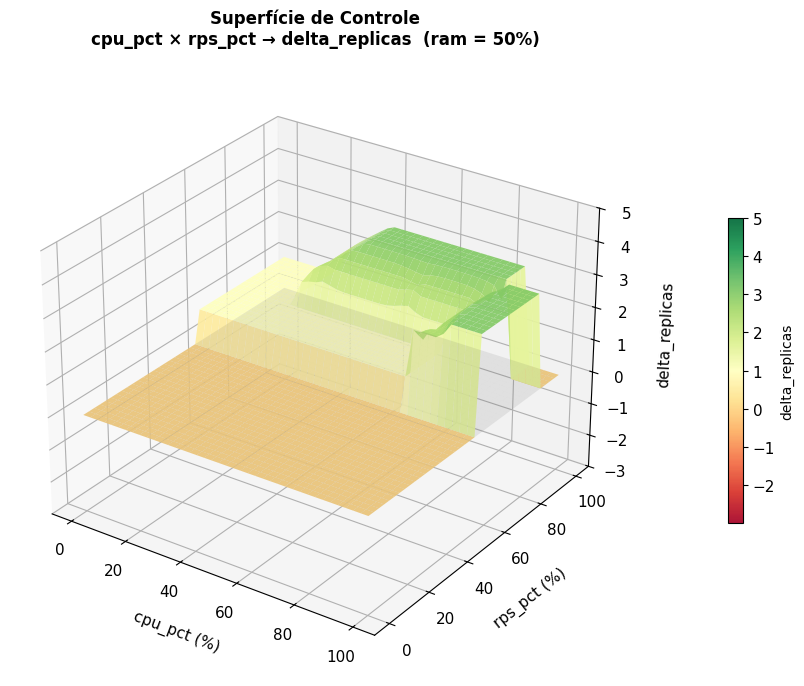

Salvo: control_surface.png


In [4]:
resolution = 40
cpu_range = np.linspace(0, 100, resolution)
rps_range = np.linspace(0, 100, resolution)
RAM_FIXED = 50.0

Z = np.zeros((resolution, resolution))
for i, cpu in enumerate(cpu_range):
    for j, rps in enumerate(rps_range):
        Z[i, j] = infer(cpu, RAM_FIXED, rps).delta_raw

CPU, RPS = np.meshgrid(cpu_range, rps_range, indexing='ij')

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(CPU, RPS, Z,
                       cmap='RdYlGn', vmin=-3, vmax=5,
                       linewidth=0, antialiased=True, alpha=0.92)

ax.set_xlabel('cpu_pct (%)', labelpad=10)
ax.set_ylabel('rps_pct (%)', labelpad=10)
ax.set_zlabel('delta_replicas', labelpad=10)
ax.set_title('Superfície de Controle\ncpu_pct × rps_pct → delta_replicas  (ram = 50%)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_zlim(-3, 5)
ax.view_init(elev=28, azim=-55)

cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('delta_replicas', fontsize=10)
cbar.set_ticks([-2, -1, 0, 1, 2, 3, 4, 5])

# plano z=0 como referência
ax.plot_surface(CPU, RPS, np.zeros_like(Z),
                alpha=0.10, color='gray', linewidth=0)

plt.tight_layout()
plt.savefig('control_surface.png', dpi=180, bbox_inches='tight')
plt.show()
print('Salvo: control_surface.png')

## 4. Superfície de controle 2D (heatmap) — visão de cima

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(Z.T, origin='lower', aspect='auto',
               extent=[0, 100, 0, 100],
               cmap='RdYlGn', vmin=-3, vmax=5)

# contorno z=0 (fronteira escala/derruba)
cs = ax.contour(cpu_range, rps_range, Z.T, levels=[0],
                colors='black', linewidths=1.5, linestyles='--')
ax.clabel(cs, fmt='Δ=0', fontsize=9)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('delta_replicas', fontsize=10)
cbar.set_ticks([-2, -1, 0, 1, 2, 3, 4, 5])

ax.set_xlabel('cpu_pct (%)')
ax.set_ylabel('rps_pct (%)')
ax.set_title('Heatmap da Superfície de Controle\n(ram = 50%)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('control_surface_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print('Salvo: control_surface_heatmap.png')